# Titanic Dataset — Exploratory Data Analysis

**Dataset:** Kaggle Titanic Dataset  
**Goal:** Understand what factors influenced survival on the Titanic  
**Author:** Isaac

In [67]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

# 1. Load & Inspect

In [2]:
filepath = 'Titanic-Dataset.csv'
my_data = pd.read_csv(filepath)
my_data


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


View the dataset

In [3]:
my_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
my_data.shape

(891, 12)

In [5]:
my_data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [6]:
my_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data Cleaning

Drop Cabin Column since more than 50% of data are missing. 

In [7]:
my_data = my_data.drop(columns = 'Cabin')

Fill age with median value of age data.

In [8]:
my_data['Age'] = my_data['Age'].fillna(my_data['Age'].median())

Fill Embarked data with the mode. 

In [9]:
my_data['Embarked'] = my_data['Embarked'].fillna(my_data['Embarked'].mode()[0])

Drop unnessary data: PassengerId, Name, Ticket

In [10]:
my_data = my_data.drop(columns = ['PassengerId', 'Name', 'Ticket'])

Check

In [11]:
print(my_data.isnull().sum())
my_data.head()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 3. Visualization

Text(0.5, 1.0, 'Number of Survived')

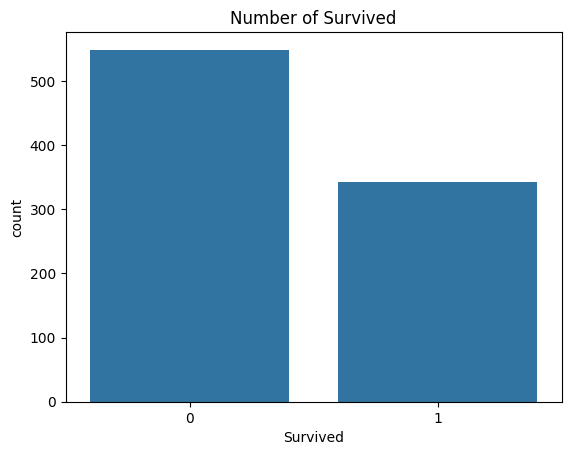

In [25]:
sns.countplot(my_data, x = 'Survived')
plt.title('Number of Survived')

In [30]:
survived = len(my_data[my_data['Survived'] == 1])
dead = len(my_data[my_data['Survived'] == 0])
print("Survived: ", survived, " / Dead: ", dead)
print(f"{survived/(survived+dead) * 100:.2f}% survived")
print(f"{dead/(survived+dead) * 100:.2f}% dead")

Survived:  342  / Dead:  549
38.38% survived
61.62% dead


We can conclude that the survival rate was 38.38%. 

<Axes: xlabel='Sex', ylabel='count'>

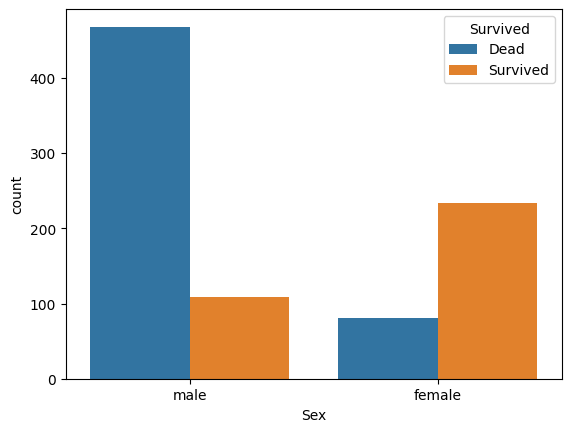

In [48]:
f2 , ax1 = plt.subplots(1, 1, sharex=True)
sns.countplot(my_data.replace(to_replace=[1,0], value=['Survived','Dead']), x = 'Sex', hue='Survived', ax = ax1)

In [68]:
sex_sur = my_data.groupby('Sex')['Survived'].value_counts()
fe_sur, fe_dead, ma_dead, ma_sur = sex_sur
table = np.array([[ma_sur, ma_dead],[fe_sur,fe_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")

Chi2: 260.7170, p-value: 0.000000, df: 1


P value < 0.05 tells us that there were significant relation between a sexulaity and a survival rate. Female had more probability of surviving comapred to male passengers. 